In [11]:
import torch, torch.nn.functional as F, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np, random, math
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# ---------- reproducibility & device ----------
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
# ---------- quick settings (tweak these for speed / fidelity) ----------
batch_size = 256
epochs = 12            # short runs for sweep — increase if you want more reliable signals
hidden1 = 128
bottleneck = 64
lr = 1e-3

# Optionally use a subset of the training set to speed up grid runs (set None to use full)
subset_frac = None   # set to 1.0 or None to disable subsetting; 0.25 is fast and indicative


In [13]:
# ---------- dataset ----------
transform = transforms.Compose([transforms.ToTensor()])
train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

if subset_frac is not None and (0 < subset_frac < 1.0):
    n = int(len(train_full) * subset_frac)
    idxs = np.random.choice(len(train_full), n, replace=False).tolist()
    train_ds = Subset(train_full, idxs)
    print(f"Using subset of train: {n}/{len(train_full)}")
else:
    train_ds = train_full

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


In [14]:
# ---------- model ----------
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=128, bottleneck=64):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden1)
        self.enc_fc2 = nn.Linear(hidden1, bottleneck)
        self.dec_fc1 = nn.Linear(bottleneck, hidden1)
        self.dec_fc2 = nn.Linear(hidden1, input_dim)
    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc1(x))
        z = torch.sigmoid(self.enc_fc2(h))
        return z
    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        x_hat = torch.sigmoid(self.dec_fc2(h))
        return x_hat
    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

# ---------- KL sparsity ----------
def kl_sparsity_loss(rho, rho_hat, eps=1e-8):
    rho_hat = torch.clamp(rho_hat, eps, 1 - eps)
    term = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
    return torch.sum(term)

# ---------- training helpers ----------
def train_ae_one_epoch(ae, opt, loader, rho, beta, device):
    ae.train()
    running = 0.0
    total = 0
    for xb, _ in loader:
        xb = xb.to(device)
        x_hat, z = ae(xb)
        recon = F.mse_loss(x_hat, xb.view(xb.size(0), -1), reduction='mean')
        rho_hat = z.mean(dim=0)
        spars = kl_sparsity_loss(rho, rho_hat)
        loss = recon + beta * spars
        opt.zero_grad(); loss.backward(); opt.step()
        bs = xb.size(0)
        running += float(recon.item()) * bs
        total += bs
    return running / total

def evaluate_ae(ae, loader, device, rho, beta):
    ae.eval()
    running_recon = 0.0
    total = 0
    all_rho_hat_sum = None
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            x_hat, z = ae(xb)
            recon = F.mse_loss(x_hat, xb.view(xb.size(0), -1), reduction='mean')
            bs = xb.size(0)
            running_recon += float(recon.item()) * bs
            rho_hat = z.mean(dim=0).cpu()
            if all_rho_hat_sum is None:
                all_rho_hat_sum = rho_hat * bs
            else:
                all_rho_hat_sum += rho_hat * bs
            total += bs
    mean_rho_hat = (all_rho_hat_sum / total).numpy()
    return running_recon / total, mean_rho_hat


In [15]:
# ---------- sweep grid ----------
rhos = [0.01, 0.05, 0.1]
betas = [1e-3, 1e-2, 1e-1]
results = {}
start_all = datetime.now()
for rho in rhos:
    for beta in betas:
        print(f"\n=== Running rho={rho:.3f}, beta={beta:.0e} ===")
        ae = SparseAutoencoder(input_dim=28*28, hidden1=hidden1, bottleneck=bottleneck).to(device)
        opt = optim.Adam(ae.parameters(), lr=lr, weight_decay=1e-5)  # small weight decay helps features
        # short training
        for ep in range(1, epochs+1):
            tr_recon = train_ae_one_epoch(ae, opt, train_loader, rho, beta, device)
            val_recon, _ = evaluate_ae(ae, val_loader, device, rho, beta)
            if ep % 4 == 0 or ep == 1 or ep == epochs:
                print(f" ep {ep:02d}/{epochs}  train_recon={tr_recon:.6f}  val_recon={val_recon:.6f}")
        # final eval: val recon + mean rho_hat over train
        val_recon, _ = evaluate_ae(ae, val_loader, device, rho, beta)
        _, mean_rho_hat = evaluate_ae(ae, train_loader, device, rho, beta)
        mean_rho = float(np.mean(mean_rho_hat))
        results[(rho, beta)] = {"val_recon": val_recon, "mean_rho_hat": mean_rho, "rho_hat_vec": mean_rho_hat}
        print(f" DONE rho={rho:.3f} beta={beta:.0e}  val_recon={val_recon:.6f} mean_rho_hat={mean_rho:.5f}")

end_all = datetime.now()
print("\nSweep finished — elapsed:", end_all - start_all)


=== Running rho=0.010, beta=1e-03 ===
 ep 01/12  train_recon=0.077983  val_recon=0.058762
 ep 04/12  train_recon=0.034809  val_recon=0.032055
 ep 08/12  train_recon=0.024768  val_recon=0.023825
 ep 12/12  train_recon=0.022005  val_recon=0.021528
 DONE rho=0.010 beta=1e-03  val_recon=0.021528 mean_rho_hat=0.08768

=== Running rho=0.010, beta=1e-02 ===
 ep 01/12  train_recon=0.099801  val_recon=0.066630
 ep 04/12  train_recon=0.060022  val_recon=0.058445
 ep 08/12  train_recon=0.051226  val_recon=0.049133
 ep 12/12  train_recon=0.038835  val_recon=0.037981
 DONE rho=0.010 beta=1e-02  val_recon=0.037981 mean_rho_hat=0.01975

=== Running rho=0.010, beta=1e-01 ===
 ep 01/12  train_recon=0.110890  val_recon=0.066753
 ep 04/12  train_recon=0.063626  val_recon=0.063881
 ep 08/12  train_recon=0.063378  val_recon=0.063430
 ep 12/12  train_recon=0.063225  val_recon=0.063421
 DONE rho=0.010 beta=1e-01  val_recon=0.063421 mean_rho_hat=0.00984

=== Running rho=0.050, beta=1e-03 ===
 ep 01/12  train

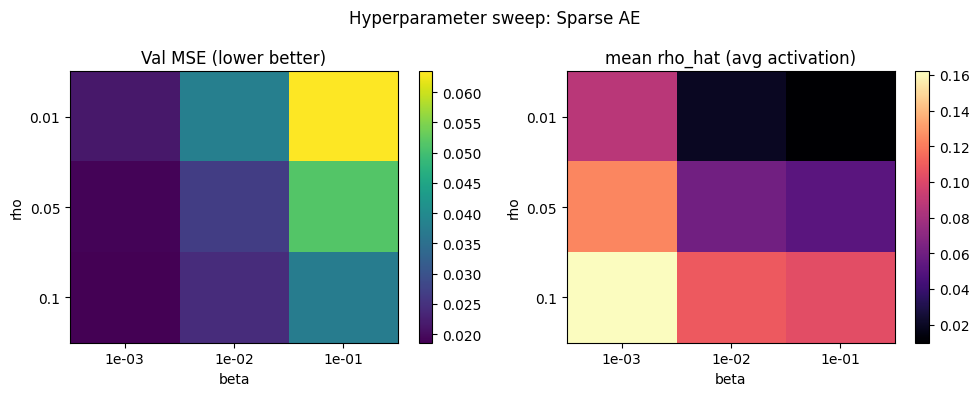


Top results sorted by val MSE (lower is better):
 rho=0.100 beta=1e-03  val_recon=0.018560  mean_rho_hat=0.16197
 rho=0.050 beta=1e-03  val_recon=0.018913  mean_rho_hat=0.12342
 rho=0.010 beta=1e-03  val_recon=0.021528  mean_rho_hat=0.08768
 rho=0.100 beta=1e-02  val_recon=0.024272  mean_rho_hat=0.10891
 rho=0.050 beta=1e-02  val_recon=0.026629  mean_rho_hat=0.06094
 rho=0.100 beta=1e-01  val_recon=0.037443  mean_rho_hat=0.10355
Saved sparse_ae_sweep_results.json


In [16]:
# ---------- present results in tables + heatmaps ----------
# prepare matrices
val_recon_mat = np.zeros((len(rhos), len(betas)))
mean_rho_mat = np.zeros_like(val_recon_mat)
for i, rho in enumerate(rhos):
    for j, beta in enumerate(betas):
        v = results[(rho, beta)]
        val_recon_mat[i, j] = v["val_recon"]
        mean_rho_mat[i, j] = v["mean_rho_hat"]

fig, axes = plt.subplots(1,2, figsize=(10,4))
im0 = axes[0].imshow(val_recon_mat, cmap='viridis', aspect='auto')
axes[0].set_xticks(range(len(betas))); axes[0].set_xticklabels([f"{b:.0e}" for b in betas])
axes[0].set_yticks(range(len(rhos))); axes[0].set_yticklabels([str(r) for r in rhos])
axes[0].set_title("Val MSE (lower better)")
axes[0].set_xlabel("beta"); axes[0].set_ylabel("rho")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mean_rho_mat, cmap='magma', aspect='auto')
axes[1].set_xticks(range(len(betas))); axes[1].set_xticklabels([f"{b:.0e}" for b in betas])
axes[1].set_yticks(range(len(rhos))); axes[1].set_yticklabels([str(r) for r in rhos])
axes[1].set_title("mean rho_hat (avg activation)")
axes[1].set_xlabel("beta"); axes[1].set_ylabel("rho")
plt.colorbar(im1, ax=axes[1])
plt.suptitle("Hyperparameter sweep: Sparse AE")
plt.tight_layout()
plt.show()

# ---------- print a neat ranking ----------
pairs_sorted = sorted(results.items(), key=lambda kv: kv[1]["val_recon"])
print("\nTop results sorted by val MSE (lower is better):")
for (rho_beta, stats) in pairs_sorted[:6]:
    rho, beta = rho_beta
    print(f" rho={rho:.3f} beta={beta:.0e}  val_recon={stats['val_recon']:.6f}  mean_rho_hat={stats['mean_rho_hat']:.5f}")

# Save results for later inspection
import json
out = {f"{r}_{b}": {"val_recon": float(v["val_recon"]), "mean_rho_hat": float(v["mean_rho_hat"])} for (r,b), v in results.items()}
with open("sparse_ae_sweep_results.json", "w") as f:
    json.dump(out, f)
print("Saved sparse_ae_sweep_results.json")